<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 14: Two-Factor Analysis of Variance (ANOVA)
**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences  
**Reference:** Chapter 12

## 1. Introduction to Two-Factor ANOVA
While a single-factor ANOVA determines if means from different groups exposed to levels of only one factor come from the same population, earth scientists frequently deal with data influenced by two or more factors simultaneously.

### Earth Science Applications:
* **Phase Equilibrium:** Investigating the combined effects of temperature and pressure on aluminosilicates.
* **Weather Patterns:** Predicting snow likelihood based on humidity and temperature.
* **Geochemistry:** Assessing seawater salinity at various depths or hydrogen diffusivity in olivine.

### The Advantage: Detecting Interactions
The most critical advantage of two-factor ANOVA is its ability to detect an **interaction** between factors. An interaction occurs when the effect of one factor is not uniform across the range of the second factor.
* **No Interaction:** A change in the first factor has the same effect regardless of the level of the second factor (lines on a graph appear parallel).
* **Interaction (Synergistic Effect):** The effect of one factor depends on the level of the other (lines appear non-parallel or crossing).

## 2. Orthogonal Designs and Partitioning Variation
In a truly **orthogonal experiment**, researchers test every possible combination of treatment levels (e.g., testing every temperature level at every humidity level). This ensures the influence of factors can be assessed independently.

### The Partitioning Formula
The analysis partitions the **total variation** (displacement of each replicate from the grand mean) into four additive components:
$$Total\ Variation = Factor\ A + Factor\ B + Interaction\ (A \times B) + Error$$

1.  **Factor A variation:** Variation caused by the levels of the first factor.
2.  **Factor B variation:** Variation caused by the levels of the second factor.
3.  **Interaction variation:** The synergistic effect resulting from the combination of both factors.
4.  **Error (Within-group variation):** Residual variation caused by random error.

ANOVA Summary Table:
                             sum_sq    df      F        PR(>F)
C(Temperature)                729.0   1.0  437.4  8.272384e-11
C(Radiation)                 1521.0   1.0  912.6  1.084191e-12
C(Temperature):C(Radiation)   225.0   1.0  135.0  6.922552e-08
Residual                       20.0  12.0    NaN           NaN


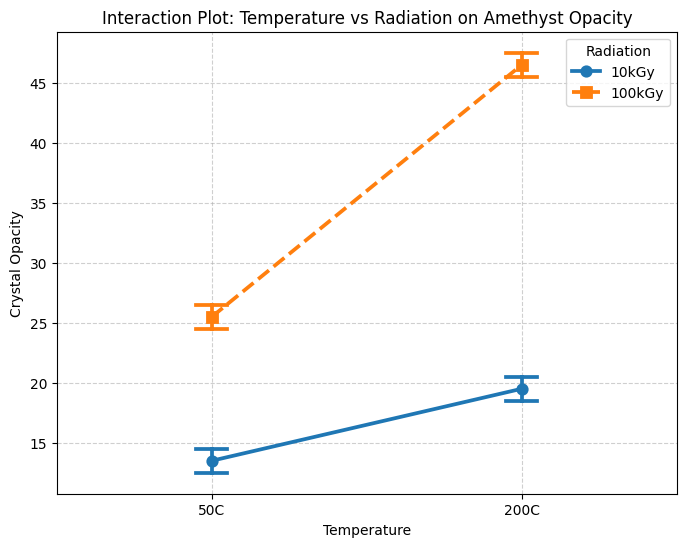

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

# [cite_start]1. Generate Synthetic Data based on the Amethyst experiment [cite: 223-228]
# Factors: Temperature (50C, 200C) and Radiation (10kGy, 100kGy)
data = {
    'Temperature': np.repeat(['50C', '200C'], 8),
    'Radiation': np.tile(np.repeat(['10kGy', '100kGy'], 4), 2),
    # Synthetic values representing an interaction effect
    'Opacity': [12, 14, 13, 15,  # 50C, 10kGy
                25, 27, 26, 24,  # 50C, 100kGy
                18, 20, 19, 21,  # 200C, 10kGy
                45, 48, 46, 47]  # 200C, 100kGy
}
df = pd.DataFrame(data)

# 2. Perform Two-Way ANOVA (Model I: Fixed Effects)
# [cite_start]The formula captures Main Effects and the Interaction (*) [cite: 76]
model = ols('Opacity ~ C(Temperature) * C(Radiation)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("ANOVA Summary Table:")
print(anova_table)

# [cite_start]3. Visualization: Interaction Plot [cite: 113, 140]
plt.figure(figsize=(8, 6))
sns.pointplot(data=df, x='Temperature', y='Opacity', hue='Radiation',
              markers=['o', 's'], linestyles=['-', '--'], capsize=.1)
plt.title('Interaction Plot: Temperature vs Radiation on Amethyst Opacity')
plt.ylabel('Crystal Opacity')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3. Essential Cautions and Model Types

### The Danger of Significant Interactions
If an ANOVA reveals a significant interaction, you **cannot** safely interpret main effects in isolation. For instance, "Temperature increases opacity" might be false if temperature only increases opacity at high radiation doses. Always use an **interaction plot** to explain the pattern before claiming main effects.

### Fixed vs. Random Factors
The calculation of the **F-ratio** (the test statistic) depends on whether factors are fixed or random:
* **Model I (Fixed):** Levels are specifically chosen (e.g., exactly 50 °C and 200 °C). Divide Factor MS by **Error MS**.
* **Model II (Random):** Levels are sampled at random from a population. Divide Factor MS by **Interaction MS**.
* **Model III (Mixed):** One fixed, one random factor. To test the fixed factor, divide its MS by the **Interaction MS**.

### A Posteriori (Post-Hoc) Testing
ANOVA is an "omnibus" test; it tells you *that* a difference exists but not *where*. If a fixed factor has **more than two levels** and is significant, run a post-hoc test like **Tukey’s test** to compare specific pairs.

In [2]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# [cite_start]Example: Post-hoc test for Temperature [cite: 130, 145]
# [cite_start]Note: In practice, only proceed if the interaction is NOT significant[cite: 133].
tukey = pairwise_tukeyhsd(endog=df['Opacity'], groups=df['Temperature'], alpha=0.05)
print("Tukey HSD Results for Temperature:")
print(tukey)

Tukey HSD Results for Temperature:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  200C    50C    -13.5 0.0306 -25.5444 -1.4556   True
-----------------------------------------------------
